# Avance 1. Análisis exploratorio de datos

**Proyecto:** AURORA  
**Nombre completo:** Análisis Unificado de Riesgo Operativo y Readiness con Aprendizaje Automático  
**Entregable:** `Avance1.4`  
**Equipo:** 4  
**Modalidad:** individual  
**Dataset:** sintético y sanitizado

## Concepto académico

AURORA es un caso de estudio académico sobre el uso de aprendizaje automático para analizar señales genéricas de calidad, riesgo y preparación de liberaciones en flujos empresariales de software. El objetivo es explorar si metadatos no sensibles pueden apoyar decisiones más trazables y basadas en evidencia sobre qué cambios requieren mayor validación antes de avanzar.

## Declaración de privacidad y confidencialidad

Este notebook usa exclusivamente datos ficticios generados de forma sintética para fines académicos. Ninguna fila, identificador, métrica, distribución o categoría corresponde a datos reales de ninguna organizacion. Por confidencialidad, no se incluyen nombres de repositorios, sistemas internos, URLs, clientes, arquitectura, tecnologías propietarias, credenciales, procedimientos operativos ni información sensible.

El objetivo es demostrar la metodología de análisis exploratorio de datos (EDA) aplicable a un caso empresarial real, sin exponer información confidencial. Las conclusiones se formulan en términos generales y no deben interpretarse como metricas reales de una organizacion.

## 1. Objetivo del EDA

El objetivo de este avance es explorar un conjunto sintético de señales relacionadas con cambios de software empresarial para identificar patrones que ayuden a anticipar riesgo y necesidades de validación.

El análisis cubre los puntos solicitados por la rúbrica:

- estructura general del dataset, tipos de datos, estadísticos descriptivos, frecuencias y valores faltantes;
- análisis univariante con visualizaciones adecuadas;
- análisis bi/multivariante para estudiar relaciones entre variables relevantes;
- preprocesamiento justificado de faltantes, atípicos y alta cardinalidad;
- conclusiones accionables sobre tendencias, relaciones y preparación para etapas posteriores de modelado.

In [1]:
# Importación de librerías y configuración inicial
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

sns.set_theme(style="whitegrid", palette="deep")
RANDOM_SEED = 42
DATA_PATH = Path("data/release_readiness_synthetic.csv")
print(f"Dataset esperado: {DATA_PATH}")

Dataset esperado: data/release_readiness_synthetic.csv


## 2. Carga del dataset sintético

El archivo CSV fue generado previamente con una semilla fija. Las variables representan metadatos genéricos de cambios de software y evidencia de validación. Se incluyen intencionalmente valores faltantes, atípicos, sesgo en algunas distribuciones, alta cardinalidad y desbalance de clases para poder aplicar las técnicas solicitadas.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
df.head()

Filas: 2,400
Columnas: 28


,change_id,week,change_type,component_area,synthetic_component_id,branch_type,validation_level,environment_profile,files_changed,lines_added,lines_deleted,modules_touched,author_experience_months,prior_failures_90d,historical_failure_rate,pipeline_duration_min,coverage_delta_pct,tests_impacted_count,critical_files_touched,documentation_refs_count,open_defects_linked,release_pressure_score,reviewer_count,validation_gap_count,readiness_score,recommended_validation_scope,failure_category,high_risk_change
0,CHG-00001,2,configuration,functional_area_b,CMP-043,development,integrated_checks,profile_standard,6,140,41,1,40.100,1,0.230,23.100,-0.760,3,0,2.000,0,60.200,2,0,80.800,focused_validation,none,0
1,CHG-00002,16,configuration,functional_area_a,CMP-001,development,basic_checks,profile_standard,8,327,78,2,15.000,3,0.184,41.400,0.090,36,0,3.000,1,30.400,7,2,71.900,expanded_validation,none,0
2,CHG-00003,14,test,functional_area_d,CMP-008,development,integrated_checks,profile_extended,11,4532,1296,2,50.100,0,0.177,21.800,-3.780,20,0,0.000,0,50.400,2,1,64.000,expanded_validation,none,0
3,CHG-00004,9,refactor,functional_area_b,CMP-002,development,broad_regression_checks,profile_standard,13,193,55,3,31.200,1,0.190,37.800,-1.350,15,0,1.000,1,3.900,1,3,59.000,broad_validation,none,0
4,CHG-00005,9,feature,functional_area_g,CMP-004,development,readiness_review,profile_extended,6,107,136,1,24.700,0,0.310,22.700,0.780,25,0,2.000,0,57.000,1,0,81.000,focused_validation,none,0


## 3. Diccionario de datos

Las variables son sintéticas y se agrupan en cinco familias:

- **Identificación y tiempo:** identificador artificial del cambio y semana sintética.
- **Contexto del cambio:** tipo de cambio, área funcional genérica, tipo de rama y perfil de ambiente.
- **Complejidad técnica:** archivos modificados, líneas agregadas/eliminadas, módulos impactados y pruebas potencialmente afectadas.
- **Evidencia de calidad:** cobertura, documentación, revisores, historial de fallas y brechas de validación.
- **Variables objetivo o de apoyo:** indicador de alto riesgo, alcance recomendado de validación, categoría de falla y puntaje de preparación.

In [3]:
data_dictionary = pd.DataFrame({
    "variable": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "descripcion_sanitizada": [
        "Identificador ficticio del cambio",
        "Semana sintética del periodo observado",
        "Tipo genérico de cambio",
        "Área funcional genérica y no propietaria",
        "Componente sintético de alta cardinalidad",
        "Tipo de rama o contexto de integración",
        "Nivel dominante de validación asociado",
        "Perfil genérico del ambiente de validación",
        "Número de archivos modificados",
        "Líneas agregadas en el cambio",
        "Líneas eliminadas en el cambio",
        "Número estimado de módulos impactados",
        "Experiencia sintética del autor en meses",
        "Fallos previos sintéticos en ventana reciente",
        "Tasa histórica sintética de falla",
        "Duración sintética de validación continua",
        "Cambio porcentual sintético en cobertura",
        "Número estimado de pruebas impactadas",
        "Indicador de archivos críticos tocados",
        "Referencias documentales sanitizadas",
        "Defectos abiertos asociados de forma sintética",
        "Presión sintética de liberación",
        "Número de revisores",
        "Brechas de evidencia o validación",
        "Puntaje sintético de preparación",
        "Alcance recomendado de validación",
        "Categoría sintética de falla",
        "Variable objetivo binaria: cambio de alto riesgo"
    ]
})
data_dictionary

,variable,tipo,descripcion_sanitizada
0,change_id,object,Identificador ficticio del cambio
1,week,int64,Semana sintética del periodo observado
2,change_type,object,Tipo genérico de cambio
3,component_area,object,Área funcional genérica y no propietaria
4,synthetic_component_id,object,Componente sintético de alta cardinalidad
5,branch_type,object,Tipo de rama o contexto de integración
6,validation_level,object,Nivel dominante de validación asociado
7,environment_profile,object,Perfil genérico del ambiente de validación
8,files_changed,int64,Número de archivos modificados
9,lines_added,int64,Líneas agregadas en el cambio


## 4. Estructura de los datos

En esta sección se revisan forma, tipos de datos, estadística descriptiva, frecuencias categóricas, duplicados y valores faltantes.

In [4]:
print("Forma del dataset:", df.shape)
print("\nTipos de datos:")
display(df.dtypes.to_frame("dtype"))

print("Duplicados por change_id:", df["change_id"].duplicated().sum())

Forma del dataset: (2400, 28)

Tipos de datos:


,dtype
change_id,object
week,int64
change_type,object
component_area,object
synthetic_component_id,object
branch_type,object
validation_level,object
environment_profile,object
files_changed,int64
lines_added,int64


Duplicados por change_id: 0


In [5]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

print(f"Variables numéricas: {len(numeric_cols)}")
print(f"Variables categóricas: {len(categorical_cols)}")

descriptive_stats = df[numeric_cols].describe().T
descriptive_stats["missing"] = df[numeric_cols].isna().sum()
descriptive_stats

Variables numéricas: 19
Variables categóricas: 9


,count,mean,std,min,25%,50%,75%,max,missing
week,"2,400.000",10.506,5.777,1.000,5.750,10.000,16.000,20.000,0
files_changed,"2,400.000",12.902,19.123,1.000,7.000,9.000,11.000,151.000,0
lines_added,"2,400.000",261.026,494.877,29.000,110.000,154.000,213.000,"4,606.000",0
lines_deleted,"2,400.000",158.772,297.111,8.000,66.000,97.000,140.000,"2,823.000",0
modules_touched,"2,400.000",2.231,2.724,1.000,1.000,2.000,2.000,22.000,0
author_experience_months,"2,292.000",35.655,20.045,1.200,20.700,32.200,46.825,144.000,108
prior_failures_90d,"2,400.000",0.913,0.947,0.000,0.000,1.000,1.000,5.000,0
historical_failure_rate,"2,400.000",0.209,0.113,0.010,0.126,0.192,0.274,0.700,0
pipeline_duration_min,"2,400.000",52.994,79.051,6.600,27.900,36.100,48.425,751.900,0
coverage_delta_pct,"2,124.000",-0.357,2.443,-9.300,-2.025,-0.320,1.333,8.840,276


In [6]:
categorical_summary = []
for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    categorical_summary.append({
        "variable": col,
        "cardinalidad_incluye_na": counts.shape[0],
        "clase_mas_frecuente": counts.index[0],
        "frecuencia_clase_mas_frecuente": int(counts.iloc[0]),
        "porcentaje_clase_mas_frecuente": round(counts.iloc[0] / len(df) * 100, 2)
    })

pd.DataFrame(categorical_summary)

,variable,cardinalidad_incluye_na,clase_mas_frecuente,frecuencia_clase_mas_frecuente,porcentaje_clase_mas_frecuente
0,change_id,2400,CHG-00001,1,0.040
1,change_type,6,feature,607,25.290
2,component_area,8,functional_area_b,456,19.000
3,synthetic_component_id,119,CMP-001,468,19.500
4,branch_type,3,development,1636,68.170
5,validation_level,5,integrated_checks,615,25.620
6,environment_profile,4,profile_standard,1332,55.500
7,recommended_validation_scope,4,expanded_validation,904,37.670
8,failure_category,7,none,1538,64.080


In [7]:
for col in categorical_cols:
    print(f"\n{col}")
    display(df[col].value_counts(dropna=False).head(12).to_frame("frecuencia"))


change_id


,frecuencia
change_id,
CHG-00001,1
CHG-01595,1
CHG-01597,1
CHG-01598,1
CHG-01599,1
CHG-01600,1
CHG-01601,1
CHG-01602,1
CHG-01603,1



change_type


,frecuencia
change_type,
feature,607
bugfix,568
configuration,347
refactor,320
test,307
dependency,251



component_area


...

,frecuencia
environment_profile,
profile_standard,1332
profile_extended,437
profile_dependency,329
profile_distributed,302



recommended_validation_scope


,frecuencia
recommended_validation_scope,
expanded_validation,904
broad_validation,689
focused_validation,404
readiness_review,403



failure_category


,frecuencia
failure_category,
none,1538
quality_regression,192
validation_issue,188
execution_context_issue,171
insufficient_evidence,133
compatibility_issue,94
NaN,84


In [8]:
missing_summary = (
    df.isna().sum()
    .to_frame("faltantes")
    .assign(porcentaje=lambda x: (x["faltantes"] / len(df) * 100).round(2))
    .query("faltantes > 0")
    .sort_values("porcentaje", ascending=False)
)
missing_summary

,faltantes,porcentaje
coverage_delta_pct,276,11.500
documentation_refs_count,168,7.000
author_experience_months,108,4.500
failure_category,84,3.500


### Observaciones iniciales de estructura

El dataset contiene variables numéricas y categóricas, por lo que el EDA requiere técnicas mixtas. La variable `synthetic_component_id` tiene alta cardinalidad de forma intencional. También existen faltantes controlados en variables de evidencia, lo cual permite estudiar patrones de ausencia y diseñar estrategias de preprocesamiento realistas sin usar datos confidenciales.

## 5. Análisis univariante

Se inspecciona cada variable relevante de forma individual. Para variables numéricas se usan histogramas y boxplots; para variables categóricas se usan barras de frecuencia.

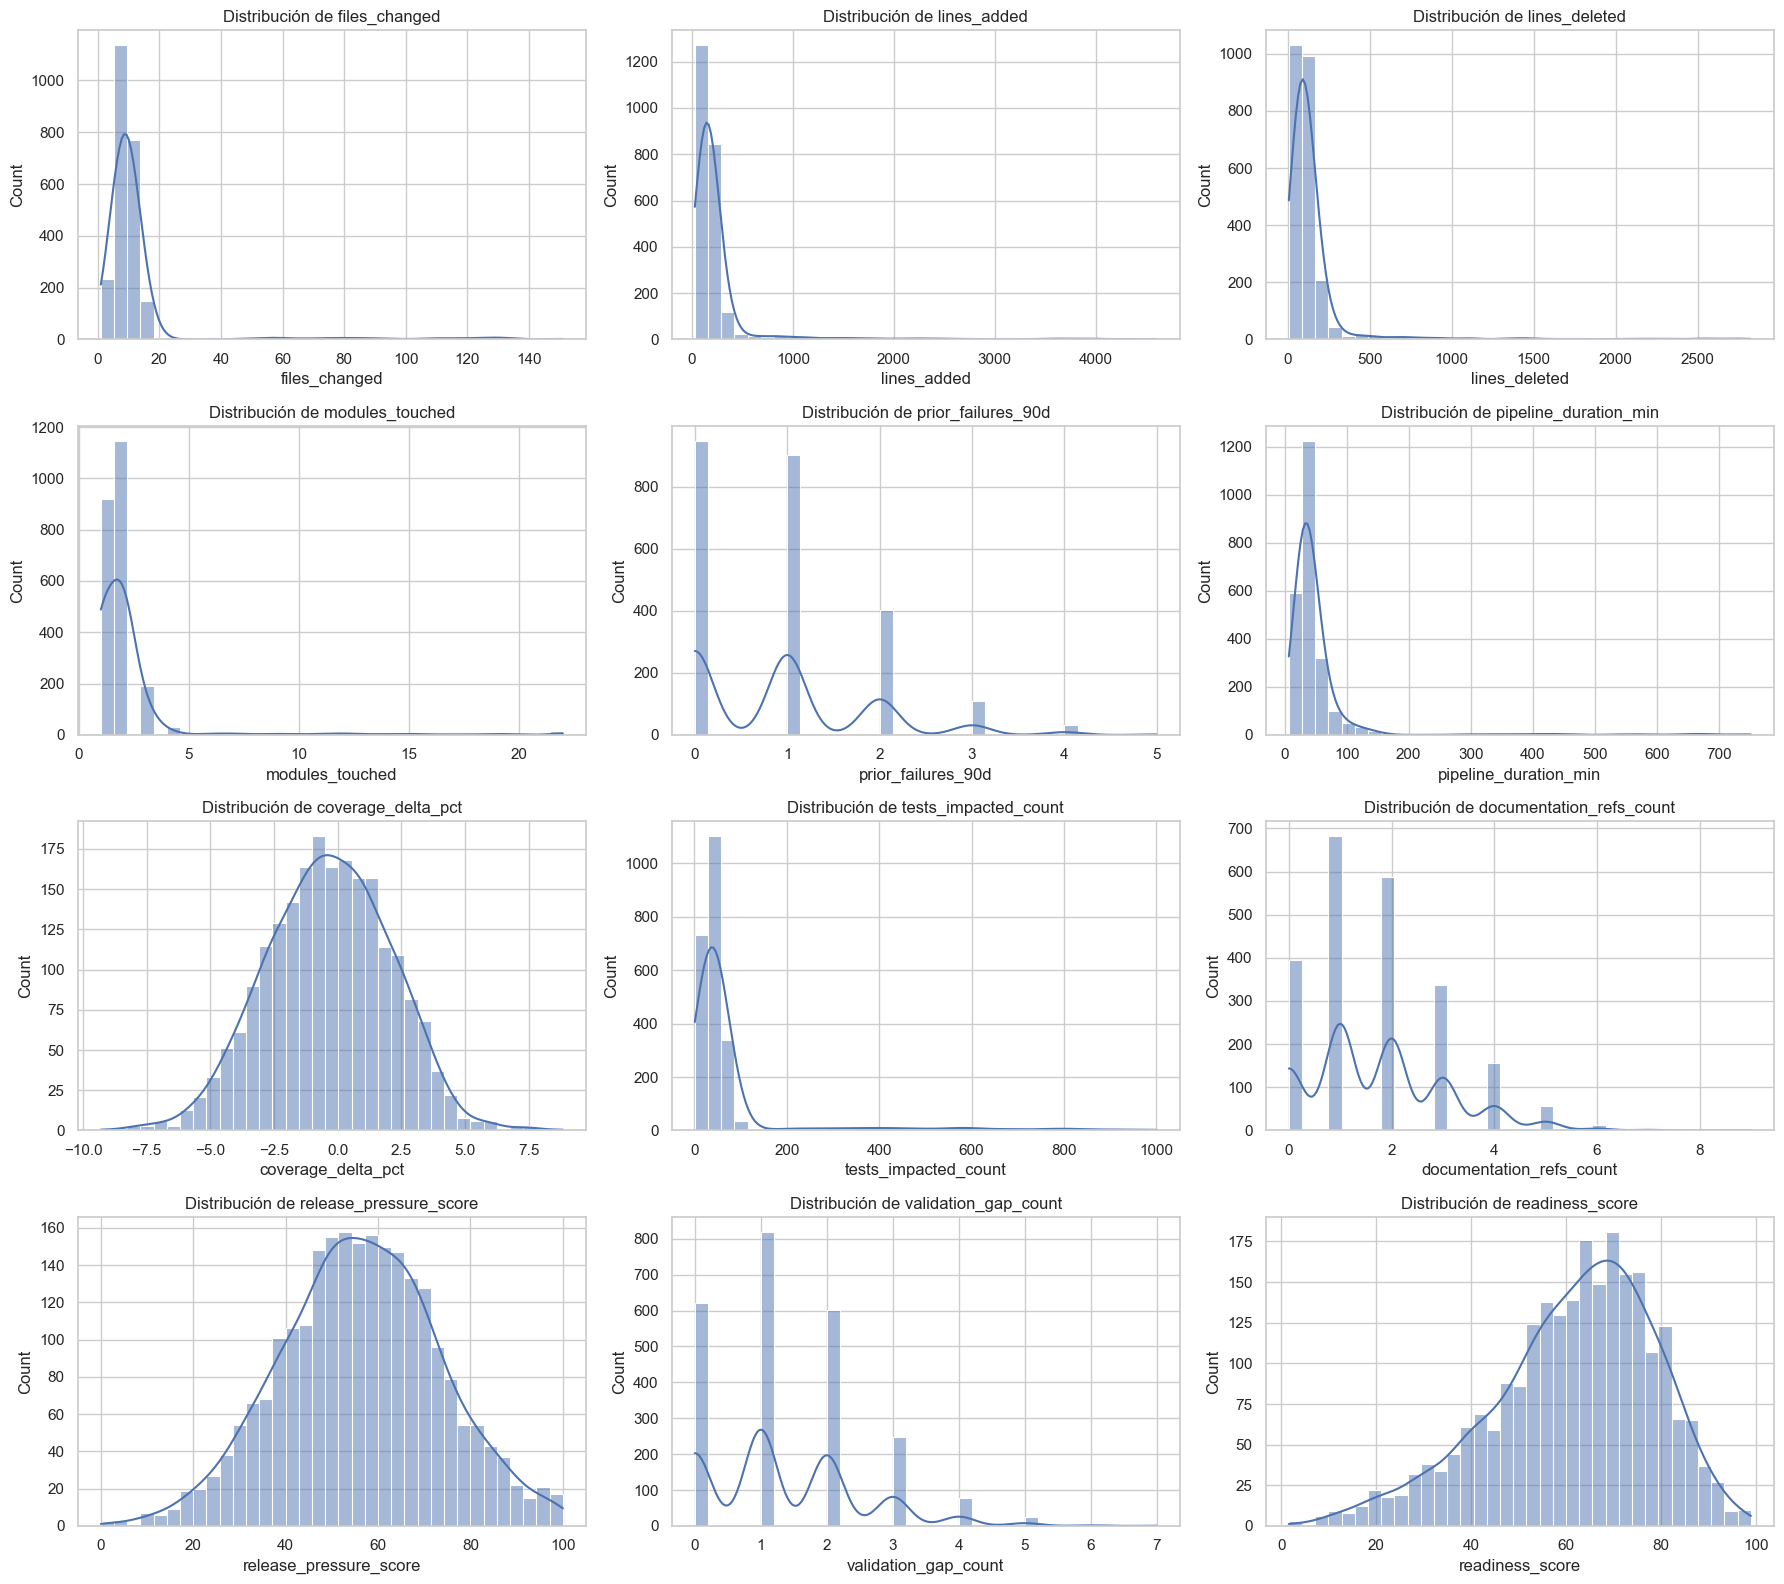

In [9]:
selected_numeric = [
    "files_changed", "lines_added", "lines_deleted", "modules_touched",
    "prior_failures_90d", "pipeline_duration_min", "coverage_delta_pct",
    "tests_impacted_count", "documentation_refs_count", "release_pressure_score",
    "validation_gap_count", "readiness_score"
]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.ravel()
for ax, col in zip(axes, selected_numeric):
    sns.histplot(df[col], kde=True, ax=ax, bins=35)
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

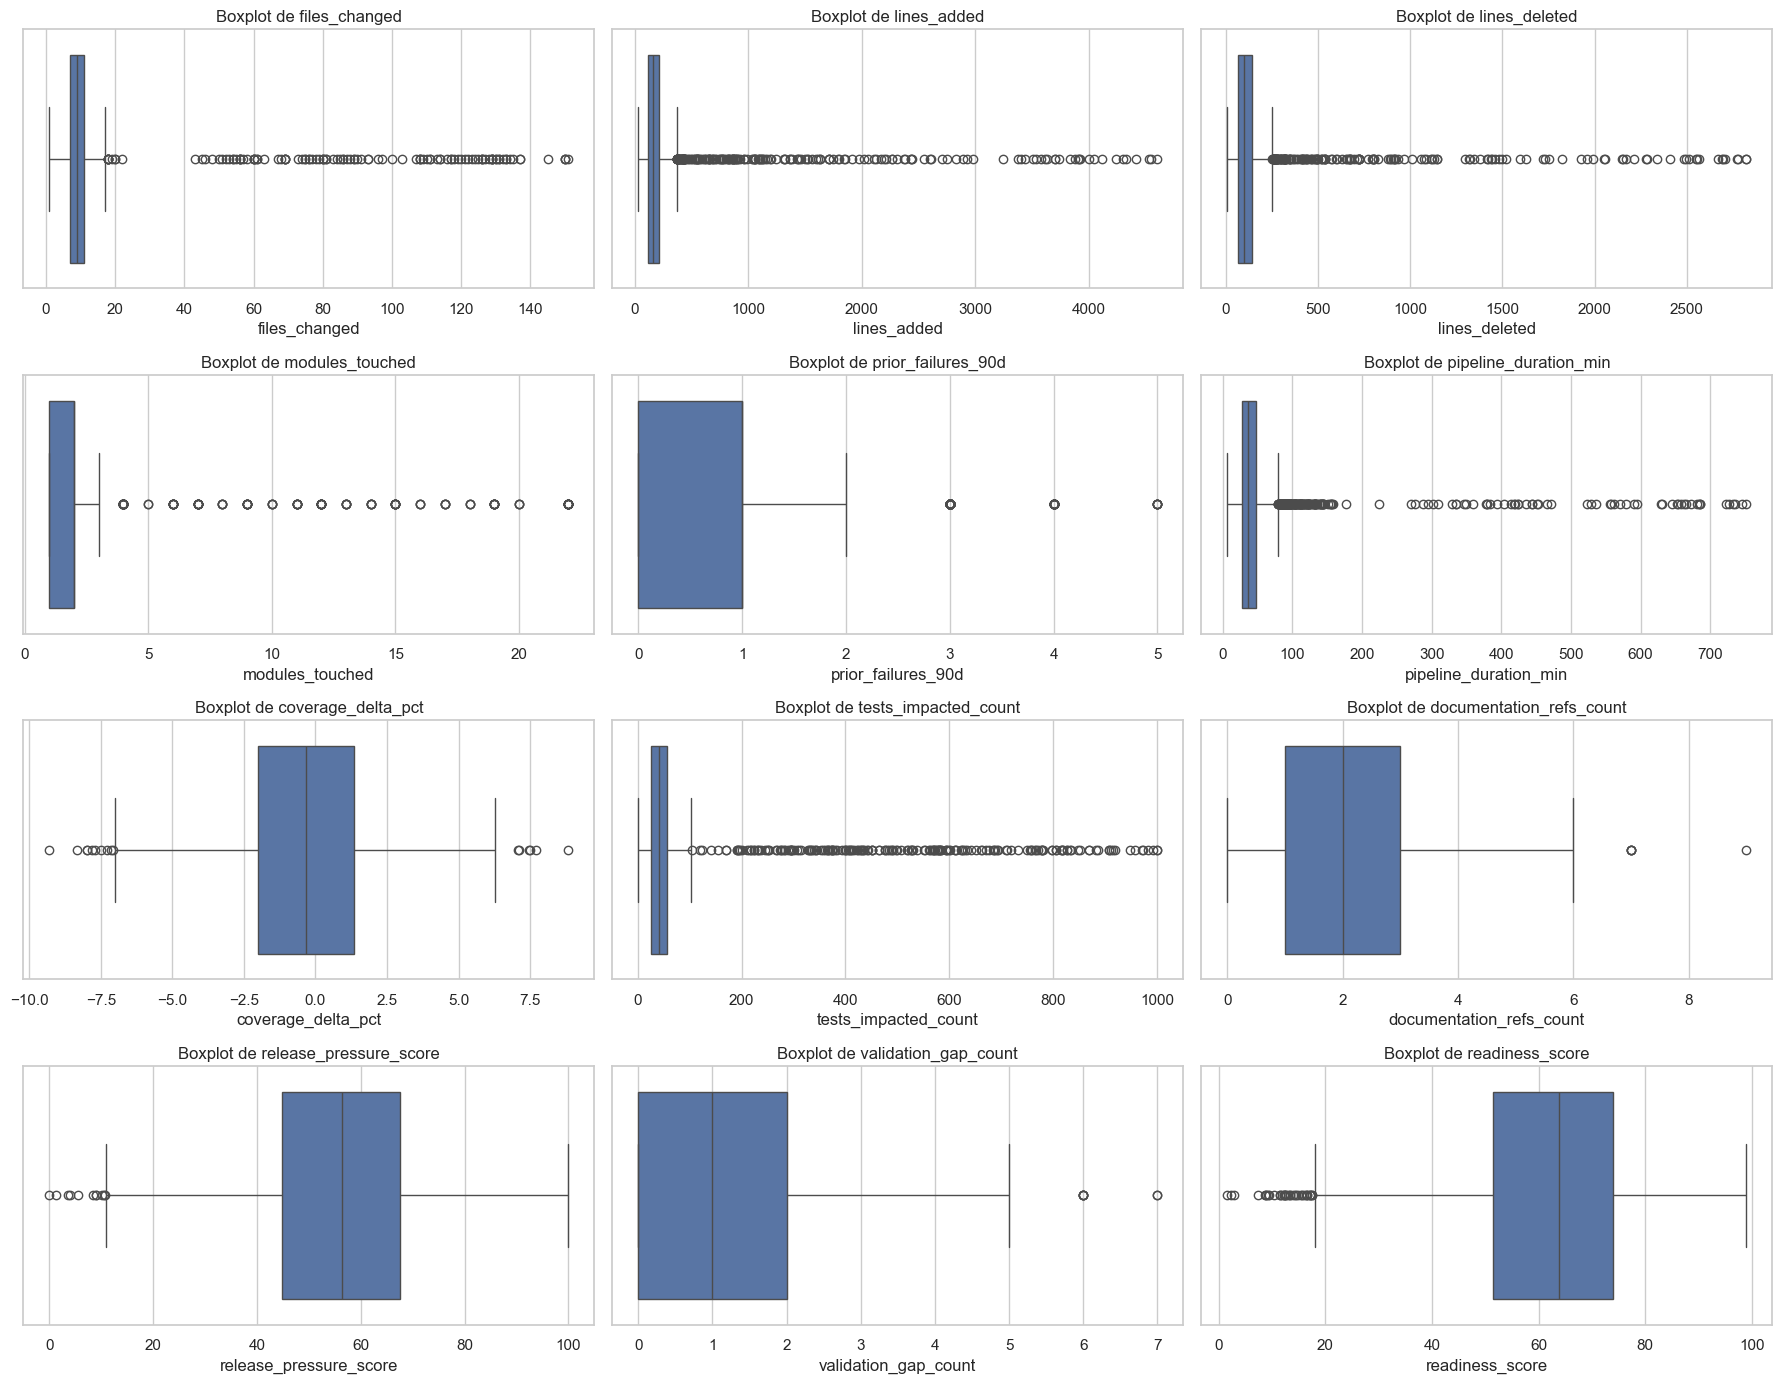

In [10]:
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.ravel()
for ax, col in zip(axes, selected_numeric):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()

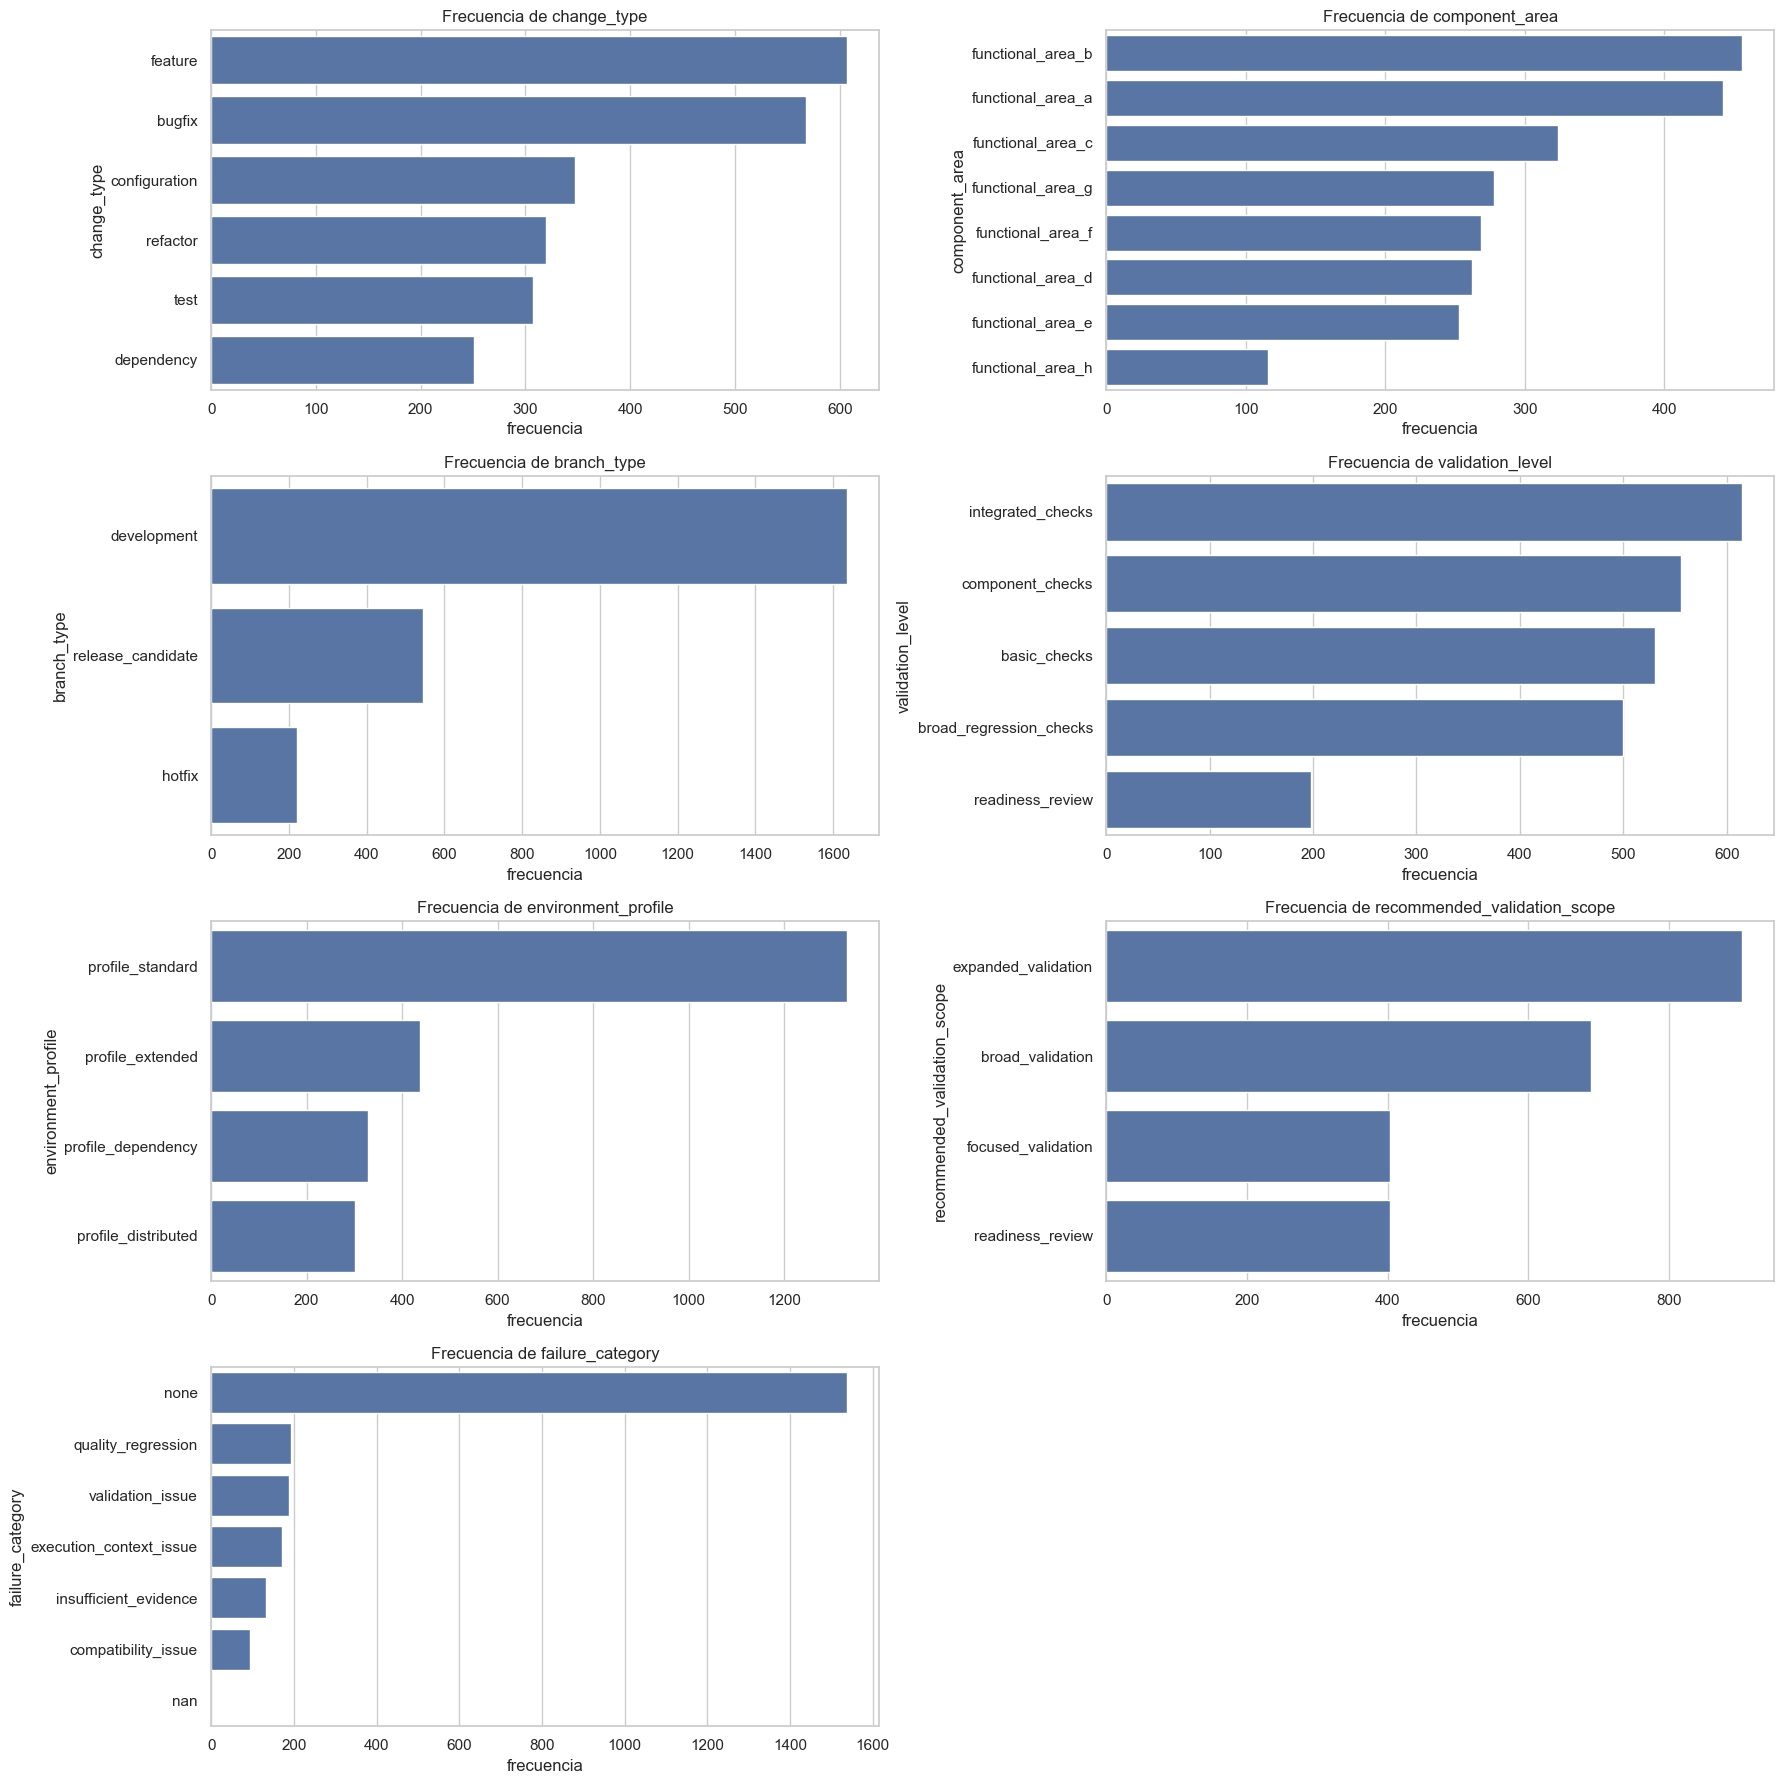

In [11]:
selected_categorical = [
    "change_type", "component_area", "branch_type", "validation_level",
    "environment_profile", "recommended_validation_scope", "failure_category"
]

fig, axes = plt.subplots(4, 2, figsize=(18, 18))
axes = axes.ravel()
for ax, col in zip(axes, selected_categorical):
    order = df[col].value_counts(dropna=False).index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(f"Frecuencia de {col}")
    ax.set_xlabel("frecuencia")
    ax.set_ylabel(col)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

,porcentaje
high_risk_change,
riesgo_no_alto,72.000
riesgo_alto,28.000


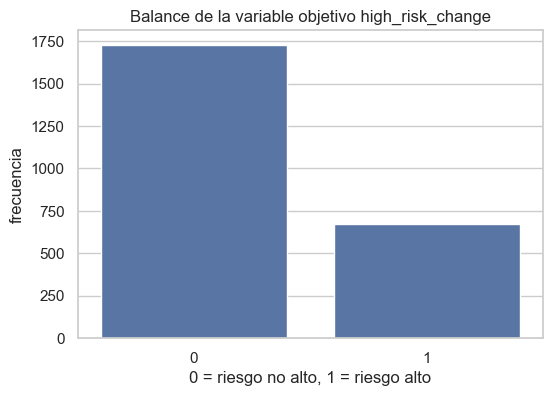

In [12]:
target_balance = df["high_risk_change"].value_counts(normalize=True).rename({0: "riesgo_no_alto", 1: "riesgo_alto"}) * 100
display(target_balance.round(2).to_frame("porcentaje"))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="high_risk_change")
plt.title("Balance de la variable objetivo high_risk_change")
plt.xlabel("0 = riesgo no alto, 1 = riesgo alto")
plt.ylabel("frecuencia")
plt.show()

### Observaciones univariantes

Las variables de tamaño y esfuerzo presentan sesgo a la derecha, algo esperado en metadatos de cambios: la mayoría de cambios son pequeños o medianos y pocos concentran un volumen alto de archivos, líneas o pruebas impactadas. La variable objetivo muestra desbalance moderado, por lo que en etapas posteriores de modelado convendría usar métricas robustas ante clases desbalanceadas.

## 6. Análisis bi/multivariante

Se estudian relaciones entre variables numéricas, variables categóricas y el indicador sintético de alto riesgo.

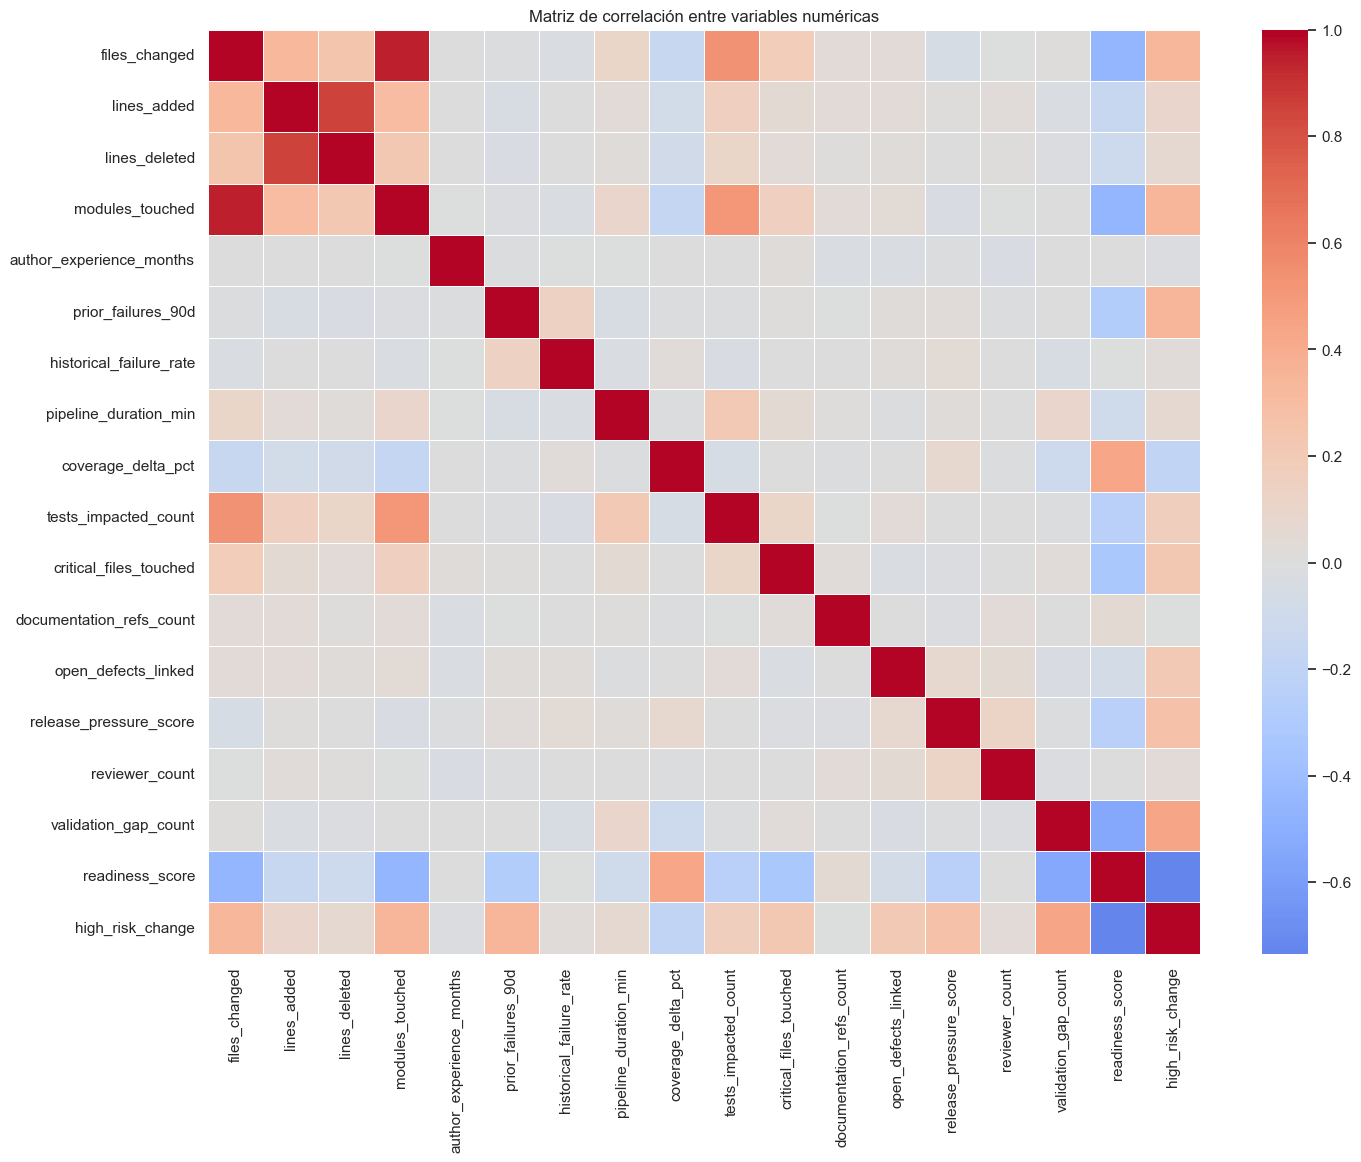

,correlacion_con_riesgo_alto
high_risk_change,1.000
validation_gap_count,0.444
prior_failures_90d,0.345
modules_touched,0.345
files_changed,0.342
release_pressure_score,0.272
critical_files_touched,0.223
open_defects_linked,0.219
tests_impacted_count,0.173
lines_added,0.094


In [13]:
corr_cols = [
    "files_changed", "lines_added", "lines_deleted", "modules_touched",
    "author_experience_months", "prior_failures_90d", "historical_failure_rate",
    "pipeline_duration_min", "coverage_delta_pct", "tests_impacted_count",
    "critical_files_touched", "documentation_refs_count", "open_defects_linked",
    "release_pressure_score", "reviewer_count", "validation_gap_count",
    "readiness_score", "high_risk_change"
]

corr = df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.4, annot=False)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

corr["high_risk_change"].sort_values(ascending=False).to_frame("correlacion_con_riesgo_alto")

In [14]:
numeric_vs_target = df.groupby("high_risk_change")[corr_cols[:-1]].mean(numeric_only=True).T
numeric_vs_target.columns = ["riesgo_no_alto", "riesgo_alto"]
numeric_vs_target["diferencia_alto_menos_no_alto"] = numeric_vs_target["riesgo_alto"] - numeric_vs_target["riesgo_no_alto"]
numeric_vs_target.sort_values("diferencia_alto_menos_no_alto", ascending=False)

,riesgo_no_alto,riesgo_alto,diferencia_alto_menos_no_alto
lines_added,231.949,335.796,103.847
tests_impacted_count,62.211,118.710,56.499
lines_deleted,145.991,191.635,45.644
files_changed,8.827,23.379,14.552
pipeline_duration_min,49.537,61.885,12.348
release_pressure_score,53.264,63.727,10.463
modules_touched,1.645,3.737,2.091
validation_gap_count,1.034,2.176,1.142
prior_failures_90d,0.709,1.438,0.728
open_defects_linked,0.516,0.935,0.419


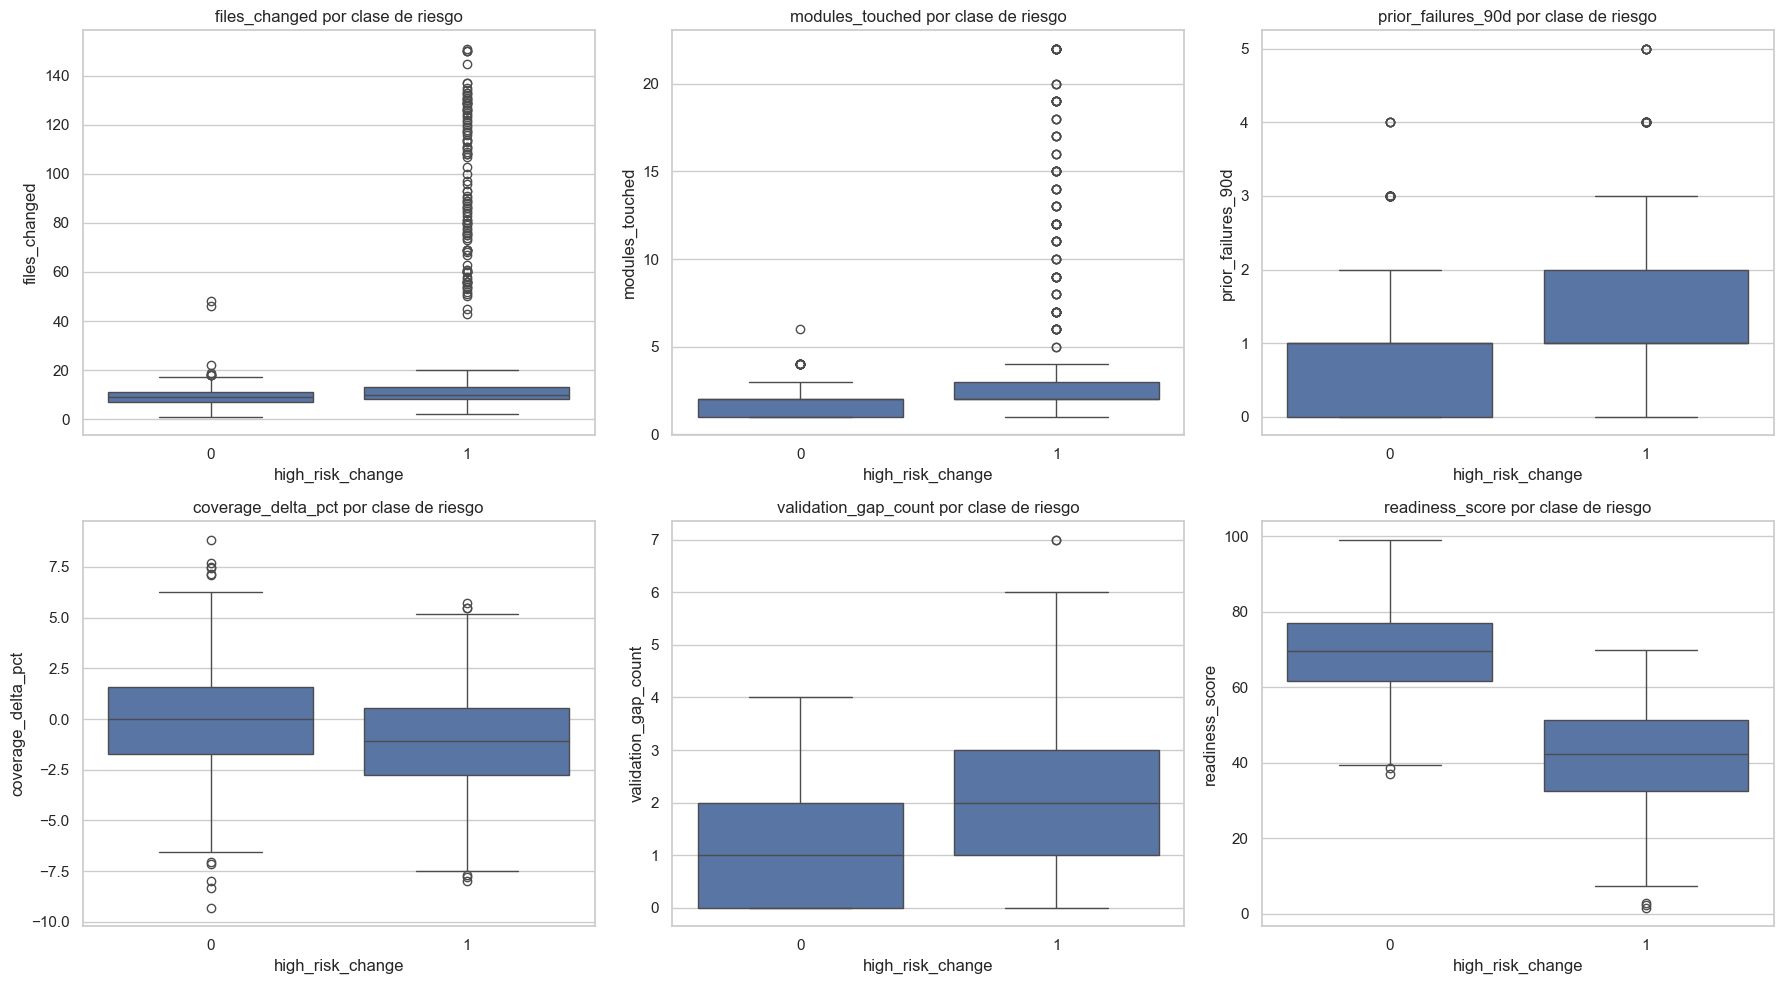

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_cols = ["files_changed", "modules_touched", "prior_failures_90d", "coverage_delta_pct", "validation_gap_count", "readiness_score"]
for ax, col in zip(axes.ravel(), plot_cols):
    sns.boxplot(data=df, x="high_risk_change", y=col, ax=ax)
    ax.set_title(f"{col} por clase de riesgo")
    ax.set_xlabel("high_risk_change")
plt.tight_layout()
plt.show()

In [16]:
def risk_rate_table(data, column):
    table = (
        data.groupby(column, dropna=False)["high_risk_change"]
        .agg(conteo="count", tasa_riesgo_alto="mean")
        .assign(tasa_riesgo_alto=lambda x: (x["tasa_riesgo_alto"] * 100).round(2))
        .sort_values("tasa_riesgo_alto", ascending=False)
    )
    return table

for col in ["change_type", "component_area", "branch_type", "validation_level", "environment_profile", "failure_category"]:
    print(f"\nTasa de alto riesgo por {col}")
    display(risk_rate_table(df, col))


Tasa de alto riesgo por change_type


,conteo,tasa_riesgo_alto
change_type,,
feature,607,32.950
configuration,347,31.120
dependency,251,31.080
refactor,320,25.000
test,307,24.100
bugfix,568,23.240



Tasa de alto riesgo por component_area


,conteo,tasa_riesgo_alto
component_area,,
functional_area_f,269,34.200
functional_area_d,262,33.970
functional_area_g,278,27.340
functional_area_h,116,26.720
functional_area_a,442,26.470
functional_area_e,253,26.090
functional_area_b,456,25.880
functional_area_c,324,25.620



Tasa de alto riesgo por branch_type


...

,conteo,tasa_riesgo_alto
validation_level,,
basic_checks,531,41.050
component_checks,556,25.360
broad_regression_checks,500,24.200
integrated_checks,615,23.900
readiness_review,198,22.730



Tasa de alto riesgo por environment_profile


,conteo,tasa_riesgo_alto
environment_profile,,
profile_dependency,329,46.810
profile_standard,1332,25.450
profile_distributed,302,24.830
profile_extended,437,23.800



Tasa de alto riesgo por failure_category


,conteo,tasa_riesgo_alto
failure_category,,
compatibility_issue,94,100.000
quality_regression,192,100.000
insufficient_evidence,133,81.200
validation_issue,188,73.940
execution_context_issue,171,69.590
NaN,84,23.810
none,1538,0.000


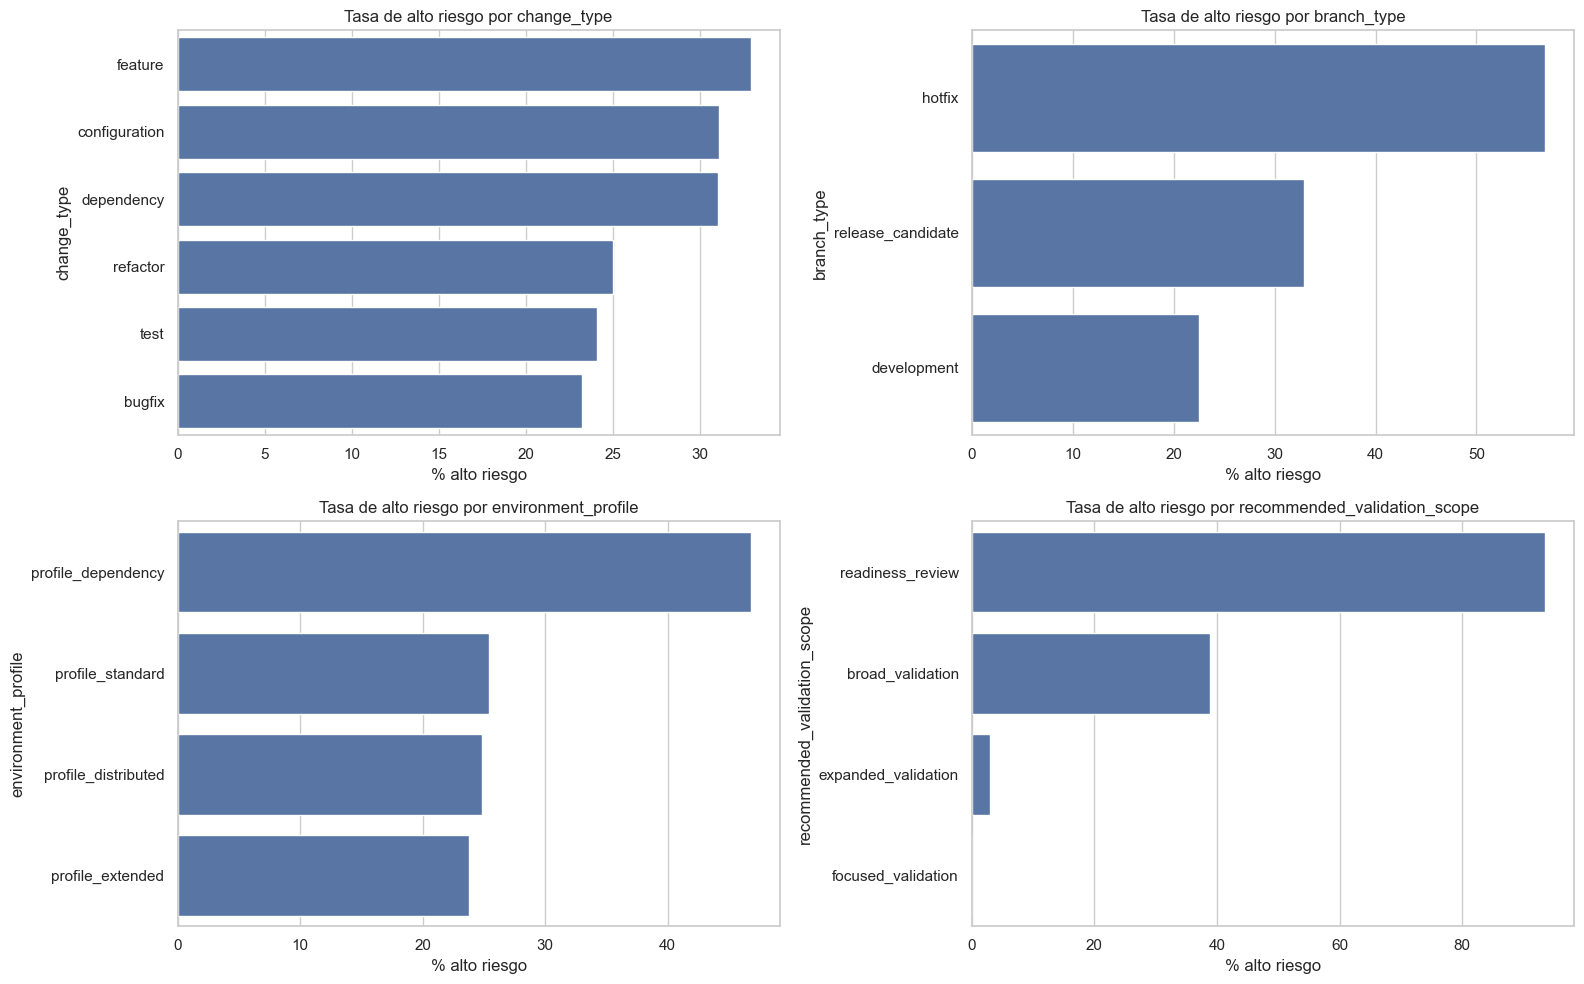

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.ravel(), ["change_type", "branch_type", "environment_profile", "recommended_validation_scope"]):
    rate = risk_rate_table(df, col).reset_index()
    sns.barplot(data=rate, y=col, x="tasa_riesgo_alto", ax=ax)
    ax.set_title(f"Tasa de alto riesgo por {col}")
    ax.set_xlabel("% alto riesgo")
plt.tight_layout()
plt.show()

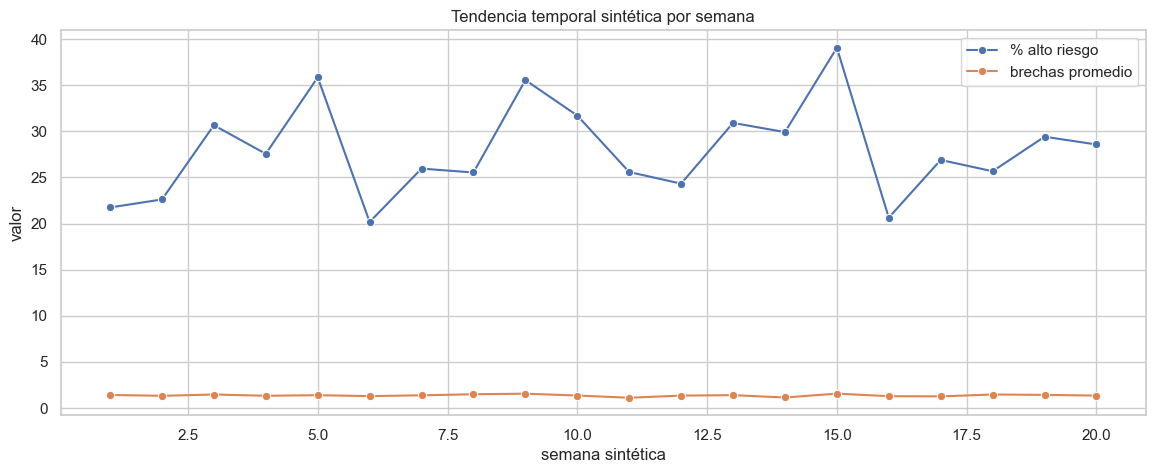

,week,cambios,tasa_riesgo_alto,readiness_promedio,gaps_promedio
0,1,115,21.739,62.800,1.400
1,2,115,22.609,60.981,1.313
2,3,137,30.657,59.561,1.453
3,4,127,27.559,61.335,1.315
4,5,106,35.849,59.896,1.377
5,6,119,20.168,63.387,1.277
6,7,131,25.954,61.295,1.366
7,8,94,25.532,61.147,1.479
8,9,135,35.556,60.630,1.541
9,10,123,31.707,60.867,1.341


In [18]:
weekly = df.groupby("week").agg(
    cambios=("change_id", "count"),
    tasa_riesgo_alto=("high_risk_change", "mean"),
    readiness_promedio=("readiness_score", "mean"),
    gaps_promedio=("validation_gap_count", "mean")
).reset_index()
weekly["tasa_riesgo_alto"] *= 100

fig, ax1 = plt.subplots(figsize=(14, 5))
sns.lineplot(data=weekly, x="week", y="tasa_riesgo_alto", marker="o", ax=ax1, label="% alto riesgo")
sns.lineplot(data=weekly, x="week", y="gaps_promedio", marker="o", ax=ax1, label="brechas promedio")
ax1.set_title("Tendencia temporal sintética por semana")
ax1.set_xlabel("semana sintética")
ax1.set_ylabel("valor")
plt.show()

weekly.head(10)

### Observaciones bi/multivariantes

El riesgo alto se asocia con mayor tamaño de cambio, más módulos impactados, mayor historial de fallas, más brechas de validación, mayor presión de liberación y menor puntaje de preparación. En cambio, mayor evidencia documental y revisión tienden a relacionarse con menor riesgo, aunque no eliminan la necesidad de validación cuando el cambio es amplio o toca zonas críticas.

## 7. Valores faltantes, atípicos y alta cardinalidad

Esta sección identifica problemas que deben corregirse antes de usar los datos en modelos predictivos. En el contexto sintético del proyecto, algunos faltantes son informativos: la ausencia de cobertura, documentación o clasificación puede representar evidencia incompleta.

In [19]:
missing_by_target = df.assign(riesgo=df["high_risk_change"].map({0: "riesgo_no_alto", 1: "riesgo_alto"}))
missing_by_target = missing_by_target.groupby("riesgo").apply(lambda frame: frame.isna().mean() * 100).T
missing_by_target = missing_by_target.loc[missing_by_target.max(axis=1) > 0].round(2)
missing_by_target

riesgo,riesgo_alto,riesgo_no_alto
author_experience_months,5.360,4.170
coverage_delta_pct,11.160,11.630
documentation_refs_count,7.590,6.770
failure_category,2.980,3.700


In [20]:
def iqr_outlier_summary(data, columns):
    rows = []
    for col in columns:
        series = data[col].dropna()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = ((series < lower) | (series > upper)).sum()
        rows.append({
            "variable": col,
            "limite_inferior_iqr": round(lower, 2),
            "limite_superior_iqr": round(upper, 2),
            "atipicos_iqr": int(outliers),
            "porcentaje_atipicos": round(outliers / len(series) * 100, 2)
        })
    return pd.DataFrame(rows).sort_values("porcentaje_atipicos", ascending=False)

outlier_summary = iqr_outlier_summary(df, selected_numeric)
outlier_summary

,variable,limite_inferior_iqr,limite_superior_iqr,atipicos_iqr,porcentaje_atipicos
5,pipeline_duration_min,-2.890,79.210,211,8.790
7,tests_impacted_count,-20.500,103.500,193,8.040
1,lines_added,-44.500,367.500,187,7.790
2,lines_deleted,-45.000,251.000,170,7.080
4,prior_failures_90d,-1.500,2.500,147,6.120
3,modules_touched,-0.500,3.500,141,5.880
0,files_changed,1.000,17.000,118,4.920
11,readiness_score,17.800,107.600,36,1.500
6,coverage_delta_pct,-7.060,6.370,16,0.750
9,release_pressure_score,10.940,101.440,11,0.460


In [21]:
cardinality = df[categorical_cols].nunique(dropna=False).sort_values(ascending=False).to_frame("cardinalidad")
cardinality

,cardinalidad
change_id,2400
synthetic_component_id,119
component_area,8
failure_category,7
change_type,6
validation_level,5
environment_profile,4
recommended_validation_scope,4
branch_type,3


### Decisiones de preprocesamiento

Se aplicarán las siguientes estrategias:

1. **Faltantes numéricos:** imputación por mediana para reducir sensibilidad a sesgos y atípicos.
2. **Indicadores de ausencia:** creación de banderas para variables donde la ausencia puede representar falta de evidencia.
3. **Faltantes categóricos:** sustitución por `unknown` para conservar el significado de ausencia.
4. **Atípicos:** winsorización por percentiles 1 y 99 en variables de conteo/duración para preservar registros extremos sin dejar que dominen escalas.
5. **Alta cardinalidad:** agrupación de componentes sintéticos raros en `other_component`.
6. **Sesgo a la derecha:** transformación logarítmica `log1p` para conteos y duración.

In [22]:
df_clean = df.copy()

# 1 y 2. Indicadores de ausencia + imputación numérica por mediana
evidence_missing_cols = ["coverage_delta_pct", "documentation_refs_count", "author_experience_months"]
for col in evidence_missing_cols:
    df_clean[f"{col}_was_missing"] = df_clean[col].isna().astype(int)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 3. Imputación categórica
df_clean["failure_category"] = df_clean["failure_category"].fillna("unknown")

# 4. Winsorización por percentiles
outlier_cols = ["files_changed", "lines_added", "lines_deleted", "pipeline_duration_min", "tests_impacted_count"]
cap_report = []
for col in outlier_cols:
    lower = df_clean[col].quantile(0.01)
    upper = df_clean[col].quantile(0.99)
    before_min, before_max = df_clean[col].min(), df_clean[col].max()
    df_clean[col] = df_clean[col].clip(lower, upper)
    cap_report.append({
        "variable": col,
        "min_antes": before_min,
        "max_antes": before_max,
        "p01_usado": round(lower, 2),
        "p99_usado": round(upper, 2),
        "min_despues": df_clean[col].min(),
        "max_despues": df_clean[col].max()
    })

# 5. Agrupación de alta cardinalidad
min_frequency = 25
component_counts = df_clean["synthetic_component_id"].value_counts()
common_components = component_counts[component_counts >= min_frequency].index
df_clean["synthetic_component_grouped"] = np.where(
    df_clean["synthetic_component_id"].isin(common_components),
    df_clean["synthetic_component_id"],
    "other_component"
)

# 6. Transformaciones log1p para variables sesgadas
log_cols = ["files_changed", "lines_added", "lines_deleted", "pipeline_duration_min", "tests_impacted_count", "open_defects_linked"]
for col in log_cols:
    df_clean[f"log1p_{col}"] = np.log1p(df_clean[col])

print("Faltantes restantes:", int(df_clean.isna().sum().sum()))
display(pd.DataFrame(cap_report))
print("Cardinalidad original synthetic_component_id:", df["synthetic_component_id"].nunique(dropna=False))
print("Cardinalidad agrupada synthetic_component_grouped:", df_clean["synthetic_component_grouped"].nunique(dropna=False))
df_clean.head()

Faltantes restantes: 0


,variable,min_antes,max_antes,p01_usado,p99_usado,min_despues,max_despues
0,files_changed,1.000,151.000,3.000,126.000,3.000,126.000
1,lines_added,29.000,"4,606.000",42.990,"3,399.410",42.990,"3,399.410"
2,lines_deleted,8.000,"2,823.000",20.000,"1,992.600",20.000,"1,992.600"
3,pipeline_duration_min,6.600,751.900,15.000,558.240,15.000,558.237
4,tests_impacted_count,1.000,"1,001.000",1.000,818.010,1.000,818.010


Cardinalidad original synthetic_component_id: 119
Cardinalidad agrupada synthetic_component_grouped: 18


,change_id,week,change_type,component_area,synthetic_component_id,branch_type,validation_level,environment_profile,files_changed,lines_added,lines_deleted,modules_touched,author_experience_months,prior_failures_90d,historical_failure_rate,pipeline_duration_min,coverage_delta_pct,tests_impacted_count,critical_files_touched,documentation_refs_count,open_defects_linked,release_pressure_score,reviewer_count,validation_gap_count,readiness_score,recommended_validation_scope,failure_category,high_risk_change,coverage_delta_pct_was_missing,documentation_refs_count_was_missing,author_experience_months_was_missing,synthetic_component_grouped,log1p_files_changed,log1p_lines_added,log1p_lines_deleted,log1p_pipeline_duration_min,log1p_tests_impacted_count,log1p_open_defects_linked
0,CHG-00001,2,configuration,functional_area_b,CMP-043,development,integrated_checks,profile_standard,6,140.000,41.000,1,40.100,1,0.230,23.100,-0.760,3.000,0,2.000,0,60.200,2,0,80.800,focused_validation,none,0,0,0,0,other_component,1.946,4.949,3.738,3.182,1.386,0.000
1,CHG-00002,16,configuration,functional_area_a,CMP-001,development,basic_checks,profile_standard,8,327.000,78.000,2,15.000,3,0.184,41.400,0.090,36.000,0,3.000,1,30.400,7,2,71.900,expanded_validation,none,0,0,0,0,CMP-001,2.197,5.793,4.369,3.747,3.611,0.693
2,CHG-00003,14,test,functional_area_d,CMP-008,development,integrated_checks,profile_extended,11,"3,399.410","1,296.000",2,50.100,0,0.177,21.800,-3.780,20.000,0,0.000,0,50.400,2,1,64.000,expanded_validation,none,0,0,0,0,CMP-008,2.485,8.132,7.168,3.127,3.045,0.000
3,CHG-00004,9,refactor,functional_area_b,CMP-002,development,broad_regression_checks,profile_standard,13,193.000,55.000,3,31.200,1,0.190,37.800,-1.350,15.000,0,1.000,1,3.900,1,3,59.000,broad_validation,none,0,0,0,0,CMP-002,2.639,5.268,4.025,3.658,2.773,0.693
4,CHG-00005,9,feature,functional_area_g,CMP-004,development,readiness_review,profile_extended,6,107.000,136.000,1,24.700,0,0.310,22.700,0.780,25.000,0,2.000,0,57.000,1,0,81.000,focused_validation,none,0,0,0,0,CMP-004,1.946,4.682,4.920,3.165,3.258,0.000


In [23]:
preprocess_summary = pd.DataFrame({
    "criterio": [
        "Valores faltantes",
        "Atípicos",
        "Alta cardinalidad",
        "Sesgo en distribuciones",
        "Privacidad"
    ],
    "estrategia_aplicada": [
        "Mediana para numéricas; unknown para categóricas; indicadores de ausencia en evidencia",
        "Winsorización p01-p99 en variables de conteo y duración",
        "Agrupación de componentes sintéticos raros en other_component",
        "Transformación log1p en conteos y duración",
        "Uso exclusivo de datos ficticios y categorías genéricas"
    ],
    "justificacion": [
        "La mediana es robusta ante asimetría; la ausencia de evidencia puede ser predictiva",
        "Preserva registros extremos sin permitir que distorsionen escalas y correlaciones",
        "Reduce dimensionalidad y mejora generalización en modelos posteriores",
        "Disminuye asimetría y estabiliza relaciones con la variable objetivo",
        "Permite demostrar metodología sin revelar datos ni tecnología interna"
    ]
})
preprocess_summary

,criterio,estrategia_aplicada,justificacion
0,Valores faltantes,Mediana para numéricas; unknown para categóric...,La mediana es robusta ante asimetría; la ausen...
1,Atípicos,Winsorización p01-p99 en variables de conteo y...,Preserva registros extremos sin permitir que d...
2,Alta cardinalidad,Agrupación de componentes sintéticos raros en ...,Reduce dimensionalidad y mejora generalización...
3,Sesgo en distribuciones,Transformación log1p en conteos y duración,Disminuye asimetría y estabiliza relaciones co...
4,Privacidad,Uso exclusivo de datos ficticios y categorías ...,Permite demostrar metodología sin revelar dato...


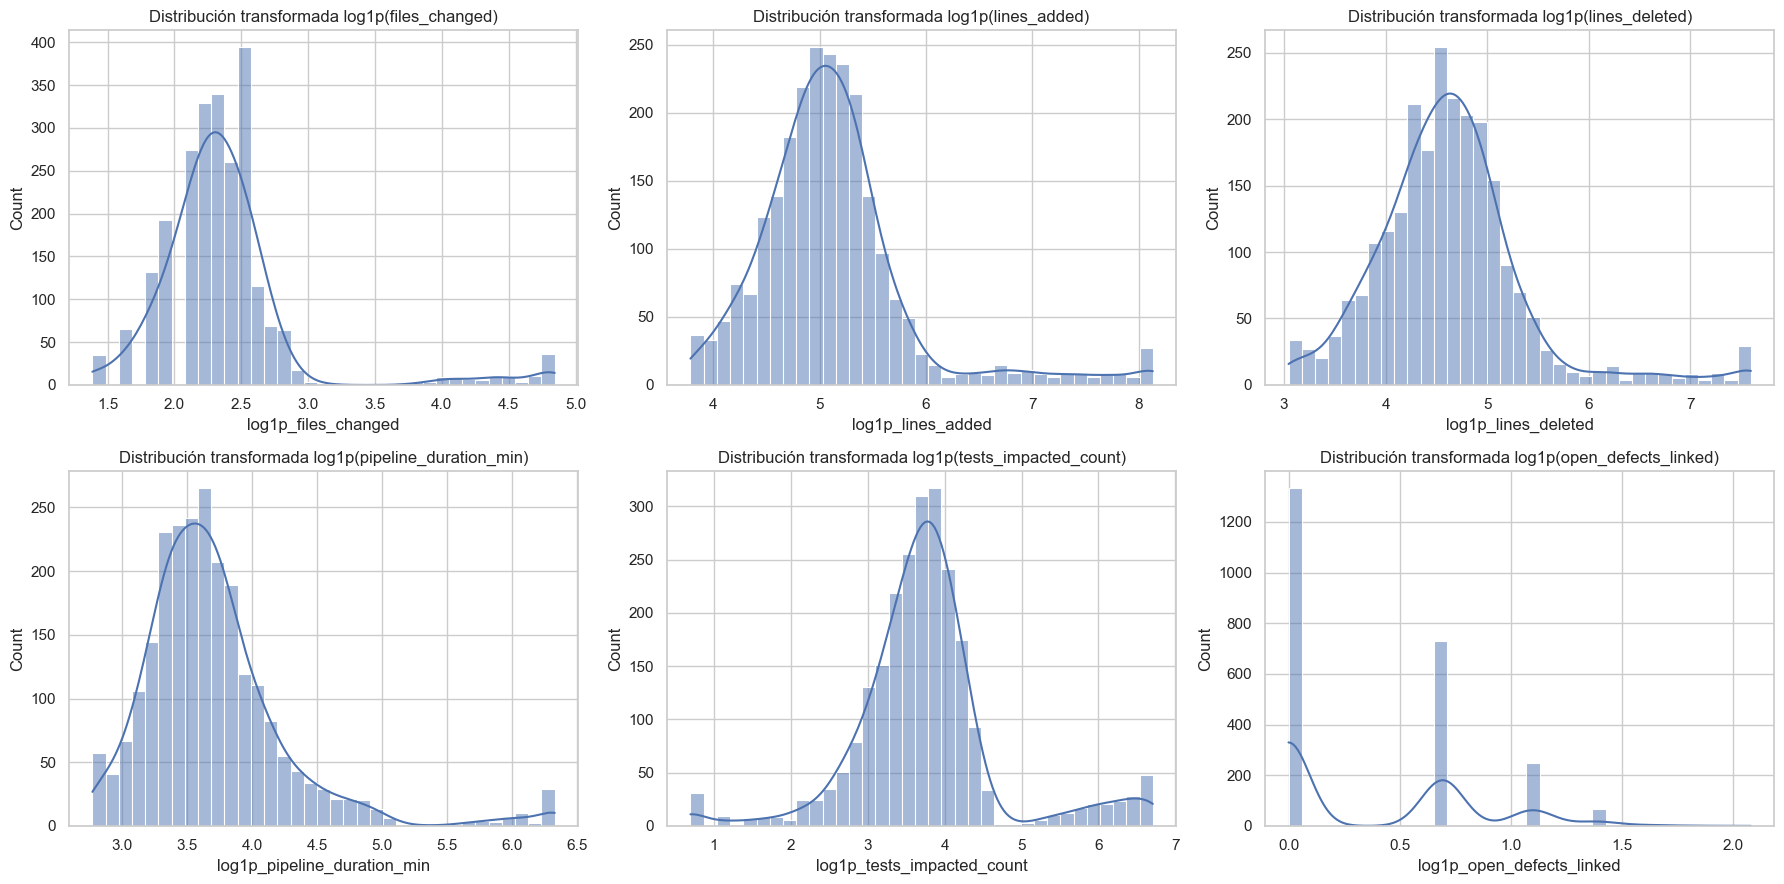

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.ravel(), log_cols[:6]):
    sns.histplot(df_clean[f"log1p_{col}"], kde=True, ax=ax, bins=35)
    ax.set_title(f"Distribución transformada log1p({col})")
plt.tight_layout()
plt.show()

## 8. Conclusiones del EDA

1. **Estructura del dataset.** El conjunto sintético tiene una mezcla de variables numéricas y categóricas, con señales de complejidad, evidencia y contexto. Esto confirma que el problema requiere un enfoque de análisis mixto, no únicamente correlaciones numéricas.

2. **Valores faltantes.** Los faltantes aparecen principalmente en variables que representan evidencia de validación o documentación. Para este proyecto, la ausencia no debe tratarse sólo como error de captura: también puede indicar falta de evidencia disponible al momento de evaluar un cambio. Por eso se justificó imputar y, además, crear indicadores de ausencia.

3. **Atípicos y sesgo.** Las variables de tamaño del cambio, duración e impacto en pruebas presentan distribuciones sesgadas a la derecha y valores extremos. Esto es consistente con escenarios empresariales donde pocos cambios concentran alta complejidad. La winsorización y las transformaciones logarítmicas preparan los datos para modelos más estables.

4. **Alta cardinalidad.** La variable de componente sintético contiene muchas categorías, por lo que agrupar clases raras reduce dimensionalidad y evita que modelos futuros memoricen componentes con poca evidencia histórica.

5. **Relaciones relevantes.** El riesgo alto tiende a aumentar cuando hay más archivos modificados, más módulos impactados, historial de fallas, brechas de validación, presión de liberación y cambios en áreas críticas genéricas. El puntaje de preparación se comporta en sentido contrario, lo que lo vuelve una señal útil para priorizar validaciones.

6. **Desbalance de clases.** La clase de alto riesgo no domina el dataset, por lo que futuras etapas de modelado deberán evitar evaluar únicamente con exactitud. Métricas como recall, precision, PR-AUC y análisis de falsos negativos serían más apropiadas.

7. **Conclusión empresarial sanitizada.** Este avance muestra que es posible construir una base analítica para priorizar validaciones y evaluar preparación de liberaciones usando metadatos no sensibles. En un entorno corporativo real, un análisis de este tipo ayuda a pasar de decisiones manuales y reactivas a decisiones trazables, explicables y basadas en evidencia, sin necesidad de exponer datos internos, tecnologías propietarias ni información operativa confidencial.

El dataset limpio `df_clean` queda listo para la siguiente etapa del proyecto: ingeniería de características y construcción de modelos predictivos.